Para este proyecto utilizaremos una base de datos de viviendas de la Ciudad de Mexico. Nuestra hipotesis es 'El precio de las viviendas crece de forma exponencial conforme las demas caracteristicas mejoran'

In [271]:
import kagglehub
import os
import pandas as pd 

# Primero, cargamos los datos
path = kagglehub.dataset_download("renecardoso/housing-prices-in-cdmx")
data = pd.read_csv(os.path.join(path, "housing_data_CDMX.csv"))

# Visualizacion rapida del dataset
print(data.info())
print(data.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  object 
 1   places                      18234 non-null  object 
 2   lat-lon                     18234 non-null  object 
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  object 
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
dtypes: float64(7), object(4)
memory usage: 1.5+ MB
None
  property_type         places                lat-lon      price currency  \
0     apartment 

DATA PREPROCESSING

Checamos la completitud

In [272]:
completitud = pd.DataFrame(data.isna().sum())
completitud = completitud.rename(columns={0:'nulos_num'})
completitud['completitud'] = (((data.shape[0] - completitud['nulos_num']) / data.shape[0]) * 100).astype('int')
print(completitud)

                            nulos_num  completitud
property_type                       0          100
places                              0          100
lat-lon                             0          100
price                               0          100
currency                            0          100
price_aprox_local_currency          0          100
price_aprox_usd                     0          100
surface_total_in_m2                 0          100
surface_covered_in_m2               0          100
price_usd_per_m2                    0          100
price_per_m2                        0          100


Exploramos cada variable

In [273]:
print(data['property_type'].value_counts(dropna=False).to_string())

property_type
apartment    13108
house         4945
store          167
PH              14


In [274]:
print(data['places'].value_counts(dropna=False).to_string())

places
BenitoJuarez          3659
MiguelHidalgo         2267
AlvaroObregon         2179
Cuauhtemoc            2126
Coyoacan              1263
GustavoAMadero        1044
Tlalpan               1044
Iztapalapa            1001
Cuajimalpa             856
Azcapotzalco           735
VenustianoCarranza     627
Iztacalco              526
MagdalenaContreras     359
Tlahuac                299
Xochimilco             247
MilpaAlta                2


In [275]:
print(data['lat-lon'].value_counts(dropna=False).to_string())

lat-lon
19.407269,-99.190754            381
23.634501,-102.552788           325
19.357350,-99.299792            209
19.371992,-99.157853            201
19.390806,-99.195413            193
19.359004,-99.092622            141
19.482945:-99.113471            119
19.401079,-99.24807             117
19.350214,-99.162146            107
19.394358,-99.177444            106
19.390415,-99.254997             98
19.39365,-99.14769               97
19.394073,-99.153915             97
19.381729,-99.164986             96
19.405298,-99.164986             82
19.441646,-99.151884             79
19.288275,-99.167125             75
19.420166,-99.220367             72
19.2990233,-99.0436467           70
19.484102,-99.184360             64
19.364891,-99.148384             63
19.341894,-99.224525             60
19.41498,-99.177444              59
19.386852,-99.194748             57
19.443178,-99.20237              56
19.410307,-99.065399             55
19.395901,-99.097612             55
19.472155,-99.161186

Tenemos 3 varaibles de precio de propiedad: price, price_aprox_local_currency, price_aprox_usd. La variable price es el valor reportado en los sitios de donde se tomo la info, sin tener en cuenta un tipo de cambio estandarizada y diferentes tazas que afectan al precio real final. La variable price_aprox_local_currency es el valor de la propiedad en la moneda nacional despues de tomar en cuenta todos los factores que afectan al precio final y que permiten comparar los precios incluso de forma internacional. La variable price_aprox_usd es simplemente price_aprox_local_currency convertida a USD, con una taza fija de 18.81 pesos por dolar.

Teniendo en cuenta esto, lo mas prudente es usar la variable price_aprox_local_currency como VARAIBLE OBJETIVO y deshacernos de las otras 2 para evitar multicolinealidad.

In [276]:
#Comprobamos price_aprox_usd = 18.81 * price_aprox_local_currency
Prueba = data['price_aprox_local_currency'] / data['price_aprox_usd']
print(Prueba.value_counts().to_string())

18.808500    809
18.808500    173
18.808500    135
18.808500    121
18.808500    105
18.808500    105
18.808500    101
18.808500     98
18.808500     82
18.808500     79
18.808500     78
18.808500     73
18.808500     72
18.808500     71
18.808500     65
18.808500     63
18.808500     63
18.808500     61
18.808500     56
18.808500     56
18.808500     54
18.808500     53
18.808500     53
18.808500     50
18.808500     50
18.808500     50
18.808500     47
18.808500     47
18.808500     46
18.808500     46
18.808500     45
18.808500     44
18.808500     44
18.808500     43
18.808500     43
18.808500     42
18.808500     42
18.808500     41
18.808500     41
18.808500     39
18.808500     38
18.808500     38
18.808500     37
18.808500     37
18.808500     37
18.808500     37
18.808500     36
18.808500     35
18.808500     35
18.808500     33
18.808500     33
18.808500     33
18.808500     33
18.808500     32
18.808500     32
18.808500     32
18.808500     32
18.808500     31
18.808500     

In [277]:
data = data.drop(columns=['price', 'price_aprox_usd'])

In [278]:
print(data['currency'].value_counts(dropna=False).to_string())

currency
MXN    17273
USD      961


Aunque todos los valores monetarios que tomaremos seran en MXN, dejamos la variable currency porque nos informa en que tipo de cambio la propiedad esta siendo anunciada, lo cual nos indica el mercado target del anuncio, cosa que tiene mucho peso en el valor comercial de la propiedad.

In [279]:
print(data['surface_total_in_m2'].value_counts(dropna=False).to_string())

surface_total_in_m2
60.0          937
70.0          894
80.0          742
65.0          625
90.0          569
50.0          438
100.0         417
75.0          395
120.0         315
85.0          285
200.0         242
55.0          226
150.0         222
64.0          194
110.0         186
160.0         177
300.0         176
250.0         170
180.0         164
63.0          163
69.0          142
95.0          140
350.0         135
220.0         132
56.0          131
58.0          130
74.0          129
68.0          127
62.0          123
130.0         123
98.0          120
78.0          118
45.0          115
67.0          112
52.0          107
54.0          104
66.0           97
57.0           96
47.0           93
83.0           92
140.0          92
44.0           91
96.0           89
88.0           88
500.0          83
97.0           82
87.0           80
240.0          76
53.0           75
107.0          75
84.0           74
61.0           74
51.0           73
42.0           72
260.0   

In [280]:
print(data['surface_covered_in_m2'].value_counts(dropna=False).to_string())

surface_covered_in_m2
60.0          936
70.0          875
80.0          741
65.0          624
90.0          557
50.0          436
100.0         413
75.0          395
120.0         302
85.0          283
55.0          224
150.0         221
200.0         218
64.0          199
110.0         182
300.0         179
250.0         168
63.0          167
180.0         156
160.0         155
350.0         151
220.0         144
56.0          143
69.0          142
95.0          139
58.0          131
74.0          131
62.0          128
68.0          128
78.0          122
130.0         121
98.0          119
54.0          115
45.0          114
67.0          111
52.0          107
57.0           99
44.0           98
66.0           95
47.0           94
83.0           89
140.0          88
88.0           85
240.0          84
96.0           81
87.0           81
97.0           80
72.0           79
400.0          78
260.0          78
79.0           77
280.0          76
61.0           76
51.0           75
53.0  

En muchos casos, surfece_total es diferente a surface_covered. Esto es porque la primera es el area total del terreno en el que se encuentra la propiedad y la segunda el area total de la superficie techada. Aunque en la mayoria de los casos surface_total es mayor (propiedades con patios), tambien hay registros en los que surface_covered es mayor debido a que puede haber propiedades con multiples pisos y con patios reducidos.

Ahora, es natural que las ultimas dos variables de precio por metro cuadrado tienen mucha correlacion con nuestra variable objetivo, que es el precio total de la vivienda. Para ver esto haremos una matriz de correlacion entre todas las varaibles numericas que nos quedan

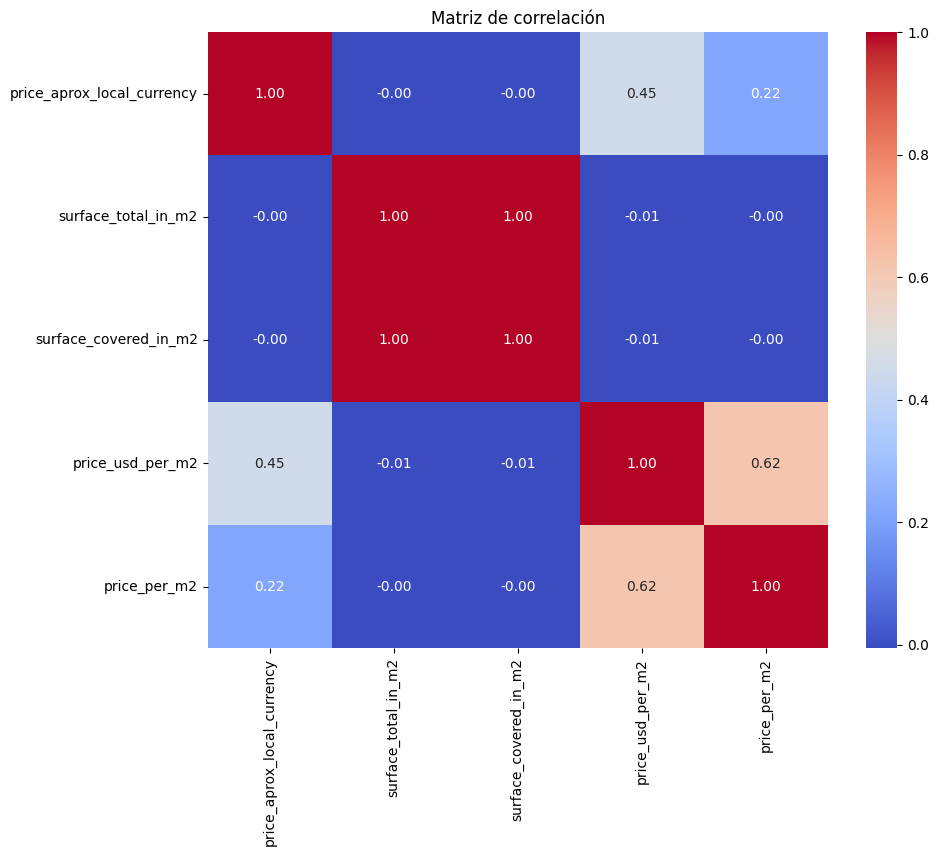

In [281]:
import seaborn as sns 
import matplotlib.pyplot as plt 

#Seleccionamos las variables numericas
dataMap = data.loc[:,['price_aprox_local_currency', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2']]

corr = dataMap.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [282]:
print(data.shape)
print(data[data['surface_total_in_m2'] == data['surface_covered_in_m2']].shape)

(18234, 9)
(16583, 9)


Vemos que de 18mil registros 16 son iguales en las variables de superficie total y superficie techada. En los registros que no sucede este, hay una clara regla relacion entre ellas, debido a que en el mapa se presenta una correlacion de 1 entre ambas. Por lo tanto decidimos eliminar la variable de superfice de superficie techada, para evitar sobreajuste.

In [283]:
data = data.drop(columns='surface_covered_in_m2')
print(data.shape)

(18234, 8)


Luego, vemos una fuerte correlacion entre precio por usd y precio en mxn, esto es normal debido al uso de una taza de cambio fija. Sin embargo vemos una importante correlacion de ambas variables con nuestra variable objetivo, lo cual era de esperarce. Entonces para evitar el data leakage, procedemos a borrar ambas varaibles.

In [284]:
data = data.drop(columns=['price_usd_per_m2', 'price_per_m2'])
print(data.shape)

(18234, 6)
